# Chapter 170 — Eigenvalues: Intuition

> **Prerequisites:** ch169 (Eigenvectors Intuition), ch158 (Determinants Intuition), ch159 (Determinants Computation)
> **You will learn:**
> - What eigenvalues measure physically and geometrically
> - How the characteristic polynomial connects determinants to eigenvalues
> - The relationship between eigenvalues and matrix properties (trace, determinant, rank)
> - How eigenvalues reveal whether a transformation expands, contracts, or inverts space
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

In ch169 we established that an eigenvector is a direction preserved by a matrix. The eigenvalue is the scalar that answers: **by how much?**

    A v = λ v

- λ > 1: the eigenvector direction gets stretched
- 0 < λ < 1: it gets compressed
- λ = 1: it is unchanged
- λ = 0: the vector collapses to zero — the transformation is singular (non-invertible)
- λ < 0: the direction is flipped and scaled

Eigenvalues are scalars extracted from a matrix that summarize its effect on space. A 2×2 matrix has 2 eigenvalues. A 3×3 has 3. They can be real, complex, or repeated.

**Common misconception:** Eigenvalues are not just the diagonal entries. Only diagonal (or triangular) matrices have this property. For general matrices, the eigenvalues must be computed from the characteristic polynomial.

## 2. Intuition & Mental Models

**Geometric:** A 2×2 matrix transforms the unit circle into an ellipse. The eigenvalues are the scaling factors along the ellipse's two axes. The eigenvectors point along those axes.

**Computational:** Think of eigenvalues as the "natural frequencies" of a linear system. Just as a guitar string has characteristic vibration frequencies, a matrix has characteristic scaling factors. They are intrinsic to the matrix — independent of coordinate system.

**Algebraic link to determinant:** From ch158, det(A) = signed volume scaling of the transformation. For a 2×2 matrix with eigenvalues λ₁ and λ₂:

    det(A) = λ₁ · λ₂

If any eigenvalue is zero, the determinant is zero, confirming singular matrix (non-invertible). The trace satisfies:

    trace(A) = λ₁ + λ₂

These two identities are not coincidences — they fall directly from expanding the characteristic polynomial.

## 3. Visualization

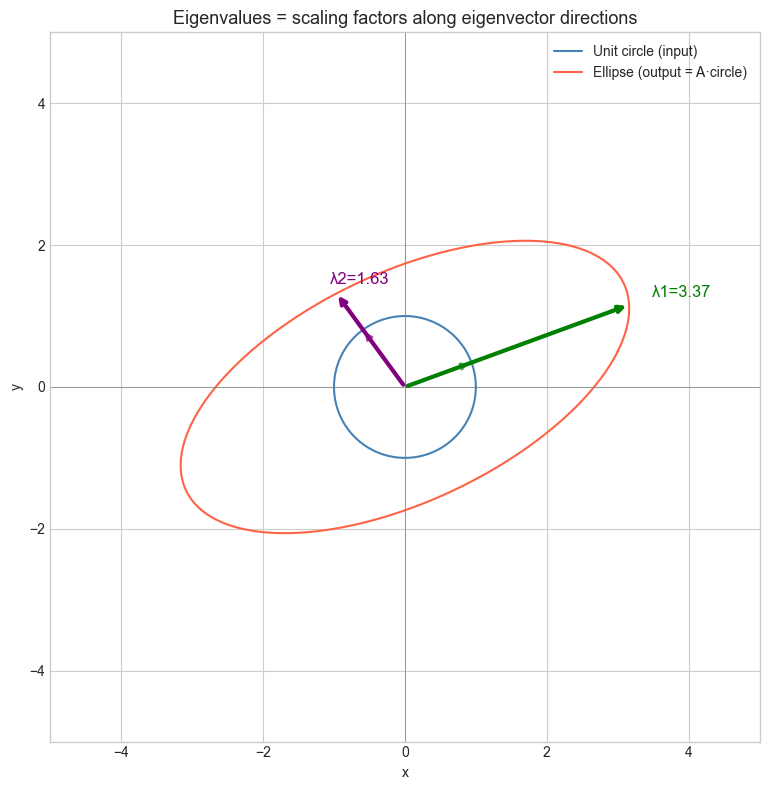

det(A) = 5.5000, λ1*λ2 = 5.5000
trace(A) = 5.0000, λ1+λ2 = 5.0000


In [1]:
# --- Visualization: Unit circle → ellipse, eigenvalues as axis lengths ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

A = np.array([[3.0, 1.0],
              [0.5, 2.0]])

eigvals, eigvecs = np.linalg.eig(A)

# Unit circle
theta = np.linspace(0, 2*np.pi, 300)
circle = np.stack([np.cos(theta), np.sin(theta)])  # (2, 300)
ellipse = A @ circle  # (2, 300)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(circle[0], circle[1], 'steelblue', lw=1.5, label='Unit circle (input)')
ax.plot(ellipse[0], ellipse[1], 'tomato', lw=1.5, label='Ellipse (output = A·circle)')

# Draw eigenvectors scaled by their eigenvalues
colors = ['green', 'purple']
for i in range(2):
    ev = eigvecs[:, i].real
    lam = eigvals[i].real
    ev_unit = ev / np.linalg.norm(ev)
    ax.annotate('', xy=ev_unit, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=colors[i], lw=2, alpha=0.7))
    ax.annotate('', xy=ev_unit * lam, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=colors[i], lw=3))
    ax.text(ev_unit[0]*lam*1.1, ev_unit[1]*lam*1.1,
            f'λ{i+1}={lam:.2f}', color=colors[i], fontsize=12)

ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_aspect('equal')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_title('Eigenvalues = scaling factors along eigenvector directions', fontsize=13)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend()
plt.tight_layout()
plt.show()
print(f"det(A) = {np.linalg.det(A):.4f}, λ1*λ2 = {np.prod(eigvals.real):.4f}")
print(f"trace(A) = {np.trace(A):.4f}, λ1+λ2 = {np.sum(eigvals.real):.4f}")

## 4. Mathematical Formulation

**Characteristic equation:** From (A - λI)v = 0, requiring a nontrivial solution:

    det(A - λI) = 0

For a 2×2 matrix A = [[a, b], [c, d]]:

    det(A - λI) = (a-λ)(d-λ) - bc = 0
    λ² - (a+d)λ + (ad-bc) = 0
    λ² - trace(A)·λ + det(A) = 0

Using the quadratic formula:

    λ = [trace(A) ± sqrt(trace(A)² - 4·det(A))] / 2

**The discriminant** trace²-4det determines the nature of eigenvalues:
- > 0: two distinct real eigenvalues
- = 0: one repeated real eigenvalue
- < 0: two complex conjugate eigenvalues (e.g., rotation matrices)

For n×n matrices, the characteristic polynomial is degree n, yielding n eigenvalues (counted over ℂ with multiplicity).

In [2]:
# Characteristic polynomial from scratch (2x2 case)
import numpy as np

def eigenvalues_2x2(A):
    """
    Compute eigenvalues of a 2x2 matrix via the characteristic polynomial.

    Args:
        A: (2,2) numpy array

    Returns:
        Tuple of two eigenvalues (may be complex)
    """
    tr = A[0,0] + A[1,1]          # trace
    det = A[0,0]*A[1,1] - A[0,1]*A[1,0]  # determinant
    discriminant = tr**2 - 4*det
    sqrt_disc = np.sqrt(complex(discriminant))
    lam1 = (tr + sqrt_disc) / 2
    lam2 = (tr - sqrt_disc) / 2
    return lam1, lam2

# Test
A = np.array([[3.0, 1.0], [0.5, 2.0]])
lam1, lam2 = eigenvalues_2x2(A)
numpy_vals = np.linalg.eigvals(A)

print(f"Our eigenvalues:   {lam1:.4f}, {lam2:.4f}")
print(f"NumPy eigenvalues: {sorted(numpy_vals.real, reverse=True)}")

# Verify trace and det relations
print(f"\ntrace(A) = {np.trace(A):.4f}, λ1+λ2 = {(lam1+lam2).real:.4f}")
print(f"det(A)   = {np.linalg.det(A):.4f}, λ1*λ2 = {(lam1*lam2).real:.4f}")

Our eigenvalues:   3.3660+0.0000j, 1.6340+0.0000j
NumPy eigenvalues: [np.float64(3.3660254037844384), np.float64(1.6339745962155614)]

trace(A) = 5.0000, λ1+λ2 = 5.0000
det(A)   = 5.5000, λ1*λ2 = 5.5000


## 5. Python Implementation

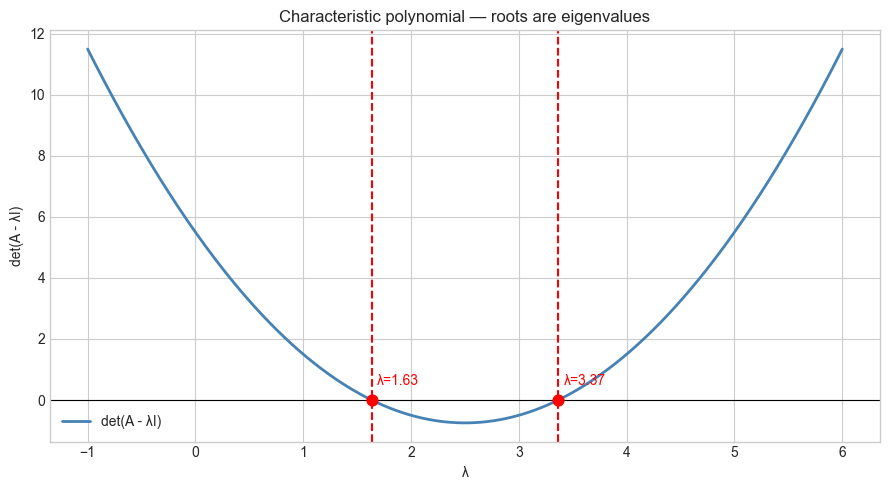

In [3]:
# --- Implementation: Visualize the characteristic polynomial ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def char_poly_2x2(A, lam):
    """
    Evaluate det(A - lambda*I) for a 2x2 matrix at given lambda values.

    Args:
        A: (2,2) numpy array
        lam: scalar or array of lambda values

    Returns:
        det(A - lambda*I) for each lambda
    """
    lam = np.atleast_1d(lam)
    results = []
    for l in lam:
        M = A - l * np.eye(2)
        results.append(M[0,0]*M[1,1] - M[0,1]*M[1,0])
    return np.array(results)

A = np.array([[3.0, 1.0], [0.5, 2.0]])
lam_range = np.linspace(-1, 6, 500)
p = char_poly_2x2(A, lam_range)

true_eigs = np.linalg.eigvals(A).real

plt.figure(figsize=(9, 5))
plt.plot(lam_range, p, 'steelblue', lw=2, label='det(A - λI)')
plt.axhline(0, color='black', lw=0.8)
for ev in true_eigs:
    plt.axvline(ev, color='red', ls='--', lw=1.5)
    plt.scatter([ev], [0], color='red', zorder=5, s=60)
    plt.text(ev+0.05, 0.5, f'λ={ev:.2f}', color='red', fontsize=10)
plt.xlabel('λ')
plt.ylabel('det(A - λI)')
plt.title('Characteristic polynomial — roots are eigenvalues')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Experiments

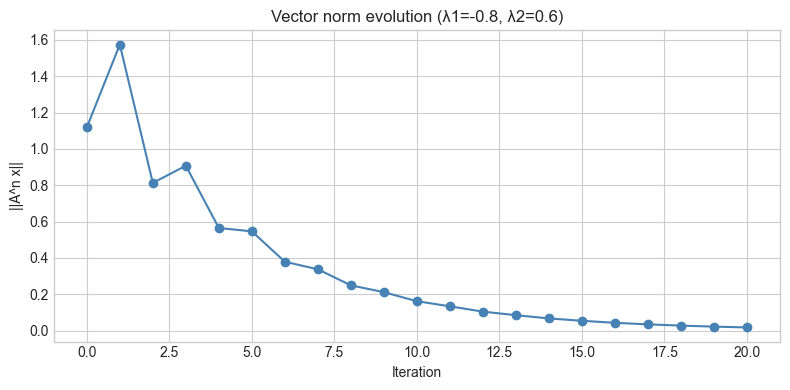

In [4]:
# --- Experiment 1: Effect of eigenvalue sign on dynamics ---
# Hypothesis: Negative eigenvalue causes oscillating behavior under repeated application
# Try changing: LAMBDA to positive, zero, or complex

import numpy as np

# Construct matrix with desired eigenvalues
LAM1 = -0.8  # try: 1.2, 0.5, 0.0, -0.8
LAM2 = 0.6

# Build A = V * diag(lam) * V^-1 with random V
np.random.seed(7)
V = np.random.randn(2, 2)
A = V @ np.diag([LAM1, LAM2]) @ np.linalg.inv(V)

# Iterate a vector
x = np.array([1.0, 0.5])
N_ITER = 20
norms = [np.linalg.norm(x)]
for _ in range(N_ITER):
    x = A @ x
    norms.append(np.linalg.norm(x))

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(8, 4))
plt.plot(norms, 'o-', color='steelblue')
plt.xlabel('Iteration')
plt.ylabel('||A^n x||')
plt.title(f'Vector norm evolution (λ1={LAM1}, λ2={LAM2})')
plt.tight_layout()
plt.show()

In [5]:
# --- Experiment 2: Eigenvalues of a rank-1 matrix ---
# Hypothesis: A rank-1 matrix has one nonzero eigenvalue and (n-1) zeros
# Try changing: the vectors u and v

import numpy as np

u = np.array([1.0, 2.0, 3.0])  # try: [1,0,0], [1,1,1]
v = np.array([4.0, 1.0, 2.0])

# Rank-1 matrix: outer product
A = np.outer(u, v)  # shape (3, 3), rank 1

eigvals = np.linalg.eigvals(A)
print(f"Rank of A: {np.linalg.matrix_rank(A)}")
print(f"Eigenvalues: {eigvals.real}")
print(f"Nonzero eigenvalue = u·v = {u @ v:.4f}")
print(f"trace(A) = {np.trace(A):.4f} = sum of eigenvalues = {eigvals.real.sum():.4f}")

Rank of A: 1
Eigenvalues: [ 1.2000000e+01 -4.6808298e-16 -4.6808298e-16]
Nonzero eigenvalue = u·v = 12.0000
trace(A) = 12.0000 = sum of eigenvalues = 12.0000


## 7. Exercises

**Easy 1.** For the matrix A = [[5, 0], [0, -2]], state the eigenvalues and eigenvectors by inspection (no computation needed). Verify with NumPy.

**Easy 2.** What is the determinant of A - λI evaluated at λ=trace(A)/2 for a 2×2 symmetric matrix? Write code to check this for three examples.

**Medium 1.** The spectral radius of a matrix is ρ(A) = max|λᵢ|. Write a function `spectral_radius(A)` and verify that for the matrix [[0.5, 0.4], [0.3, 0.6]], repeated application of A to a vector converges (norms → 0) if and only if ρ(A) < 1.

**Medium 2.** Plot the characteristic polynomial for a family of 2×2 matrices parameterized by a single off-diagonal entry k: A = [[2, k], [-k, 2]]. As k increases, what happens to the eigenvalues? At what k do they become complex?

**Hard.** A Markov matrix has all non-negative entries and column sums equal to 1 *(relevant to ch257 — Markov Chains)*. Prove that 1 is always an eigenvalue of such a matrix. Construct a 3×3 example and verify. What do the remaining eigenvalues tell you about convergence speed?

## 8. Mini Project: Eigenvalue Geometry Explorer

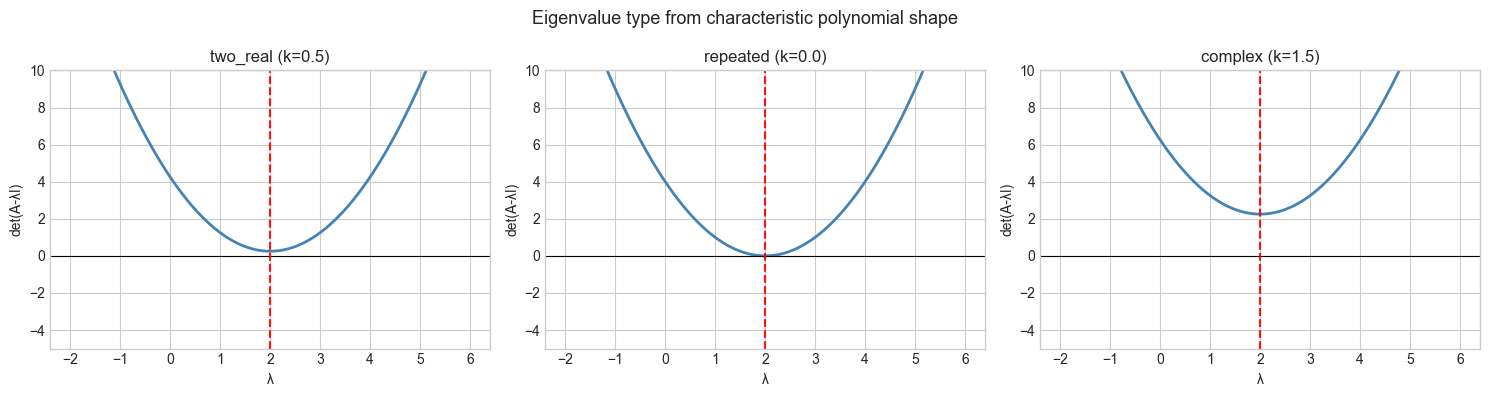

In [6]:
# --- Mini Project: Map eigenvalue type to geometric behavior ---
# Problem: Build a visualization that shows how changing a 2x2 matrix's
#          entries changes the eigenvalue type (real/complex/repeated)
#          and what each type looks like geometrically.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def classify_eigenvalues(A):
    """
    Classify a 2x2 matrix's eigenvalues.

    Returns: 'two_real', 'repeated', or 'complex'
    """
    tr = np.trace(A)
    det = np.linalg.det(A)
    disc = tr**2 - 4*det
    if abs(disc) < 1e-10:
        return 'repeated'
    elif disc > 0:
        return 'two_real'
    else:
        return 'complex'

# Sweep off-diagonal entries
K_VALUES = np.linspace(-3, 3, 200)
results = {'two_real': [], 'repeated': [], 'complex': []}

for k in K_VALUES:
    A = np.array([[2.0, k], [-k, 2.0]])
    etype = classify_eigenvalues(A)
    results[etype].append(k)

# Visualize characteristic polynomial for three cases
cases = [
    ('two_real', 0.5),
    ('repeated', 0.0),   # k=0 gives repeated λ=2
    ('complex', 1.5)
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
lam_range = np.linspace(-2, 6, 400)

for ax, (label, k) in zip(axes, cases):
    A = np.array([[2.0, k], [-k, 2.0]])
    p = [(A[0,0]-l)*(A[1,1]-l) - A[0,1]*A[1,0] for l in lam_range]
    ax.plot(lam_range, p, 'steelblue', lw=2)
    ax.axhline(0, color='black', lw=0.8)
    eigs = np.linalg.eigvals(A)
    for ev in eigs.real:
        ax.axvline(ev, color='red', ls='--', alpha=0.7)
    ax.set_title(f'{label} (k={k})')
    ax.set_xlabel('λ')
    ax.set_ylabel('det(A-λI)')
    ax.set_ylim(-5, 10)

plt.suptitle('Eigenvalue type from characteristic polynomial shape', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Chapter Summary & Connections

- Eigenvalues are scalars satisfying det(A - λI) = 0 — the roots of the characteristic polynomial.
- For a 2×2 matrix: trace(A) = λ₁+λ₂ and det(A) = λ₁·λ₂.
- The discriminant of the characteristic polynomial determines whether eigenvalues are real, repeated, or complex.
- A zero eigenvalue ↔ singular matrix ↔ lost dimension ↔ zero determinant.
- The spectral radius ρ(A) = max|λᵢ| controls whether repeated multiplication converges or diverges.

**Backward:** This extends ch158-ch159 (Determinants) — the characteristic polynomial is just the determinant of a parameterized matrix family.

**Forward:**
- ch171 (Eigenvalue Computation): QR algorithm and other numerical methods for larger matrices
- ch172 (Diagonalization): express A as V·diag(λ)·V⁻¹ when eigenvectors are linearly independent
- ch257 (Markov Chains): eigenvalues of transition matrices control long-run behavior — the dominant eigenvalue is always 1

**Going deeper:** The Gershgorin circle theorem gives eigenvalue bounds without solving the characteristic polynomial — useful for large sparse matrices.